In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error

from datetime import datetime

In [2]:
PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_global_original.npy'
lines_a_noisy = np.load(PATH_TRAINING_A)[:1000]
train_norm, val_norm = train_test_split(lines_a_noisy, test_size=0.1, random_state=42)


In [ ]:
# timesteps = 64
# features = 2
# latent_dim = 16 

# inputs = Input(shape=(timesteps, features))

# encoded = LSTM(128, return_sequences=True)(inputs)
# encoded = LSTM(64, return_sequences=True)(encoded)
# encoded = LSTM(latent_dim)(encoded)

# decoded = RepeatVector(timesteps)(encoded)
# decoded = LSTM(64, return_sequences=True)(decoded)
# decoded = LSTM(128, return_sequences=True)(decoded)
# decoded = TimeDistributed(Dense(features))(decoded)

#autoencoder = Model(inputs, decoded)

latent_dim = 64

inputs = Input(shape=(64, 2))
x = LSTM(128, return_sequences=True)(inputs)
x = LSTM(64, return_sequences=True)(x)
encoded = LSTM(latent_dim)(x)

x = RepeatVector(64)(encoded)
x = LSTM(64, return_sequences=True)(x)
x = LSTM(128, return_sequences=True)(x)
outputs = TimeDistributed(Dense(2))(x)

autoencoder = Model(inputs, outputs)

#autoencoder.summary()


In [15]:
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])

history = autoencoder.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=300,
    batch_size=32,
    shuffle=True
)


Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0536 - mae: 0.0536 - val_loss: 0.0253 - val_mae: 0.0253
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0200 - mae: 0.0200 - val_loss: 0.0159 - val_mae: 0.0159
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0157 - mae: 0.0157 - val_loss: 0.0130 - val_mae: 0.0130
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0129 - mae: 0.0129 - val_loss: 0.0115 - val_mae: 0.0115
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0119 - mae: 0.0119 - val_loss: 0.0094 - val_mae: 0.0094
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0097 - mae: 0.0097 - val_loss: 0.0095 - val_mae: 0.0095
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0097 - mae: 0.0097 - val_loss: 0.0086 - val_mae: 0.0086
Epoch 8/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0087 - mae: 0.0087 - val_loss: 0.0116 - val_mae: 0.0116
Epoch 9/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - l

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


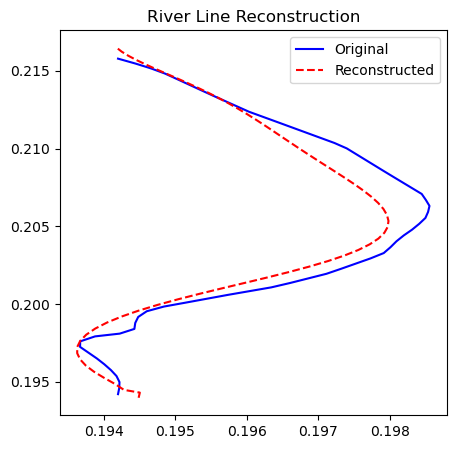

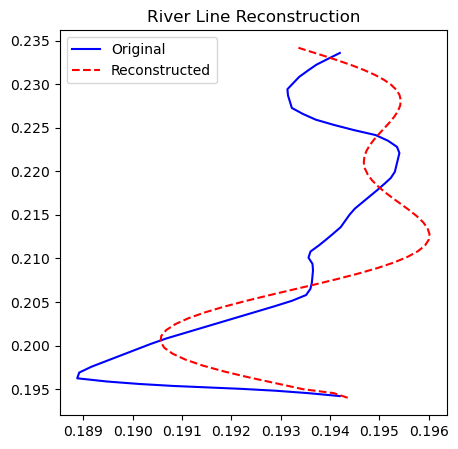

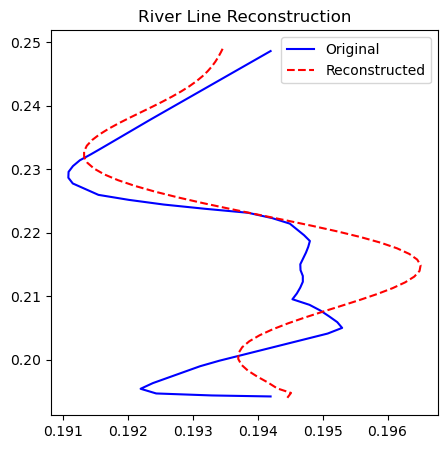

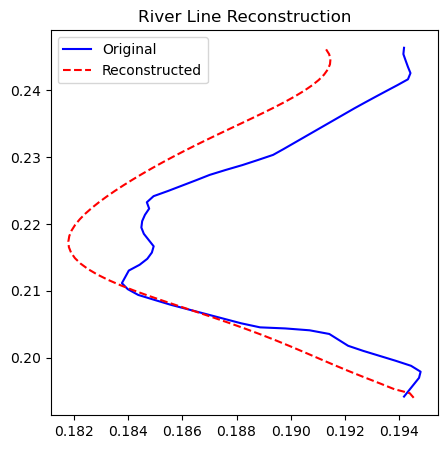

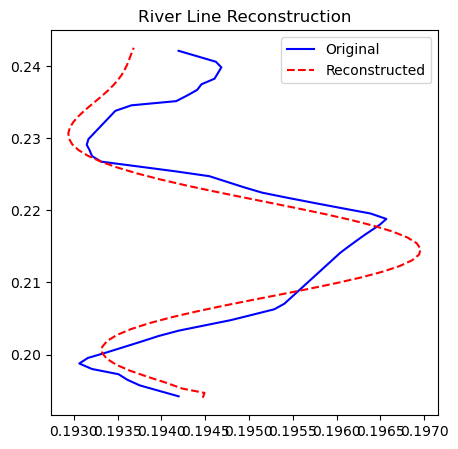

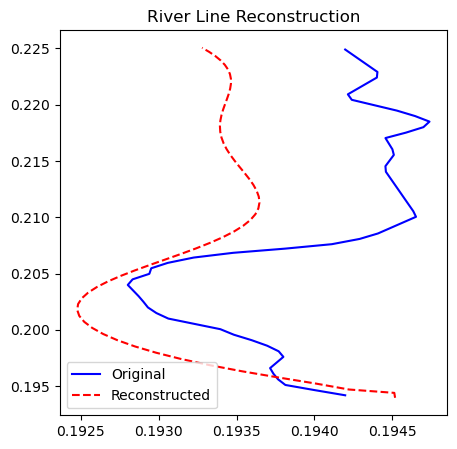

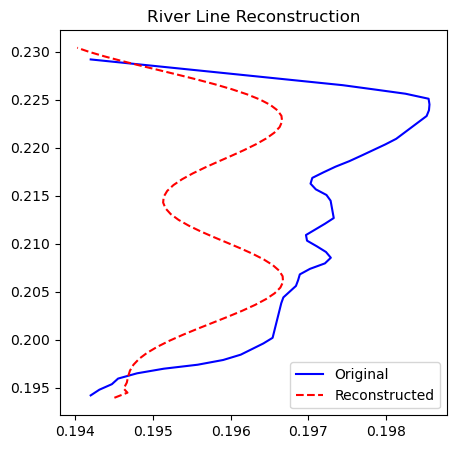

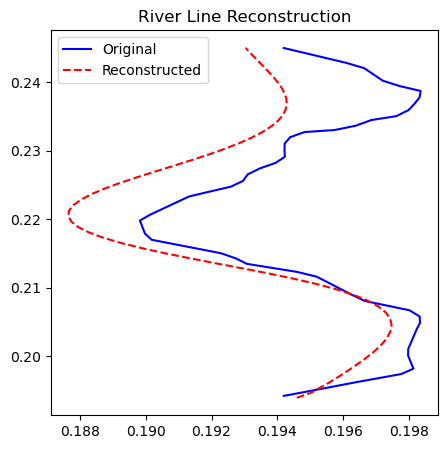

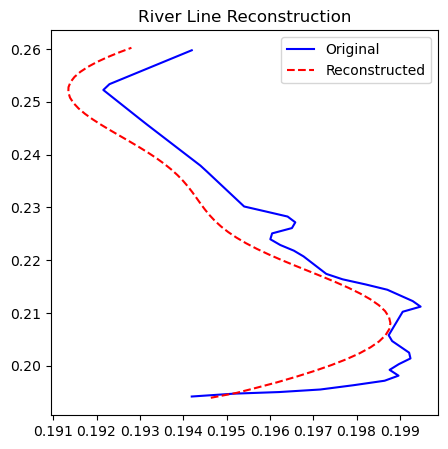

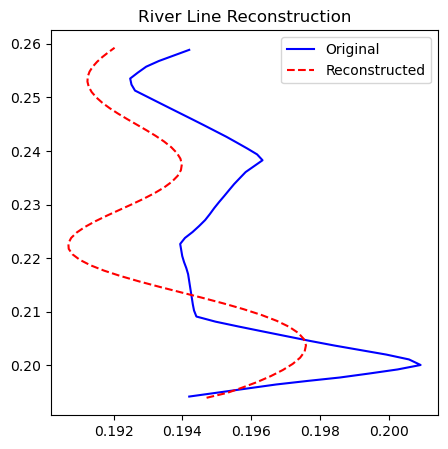

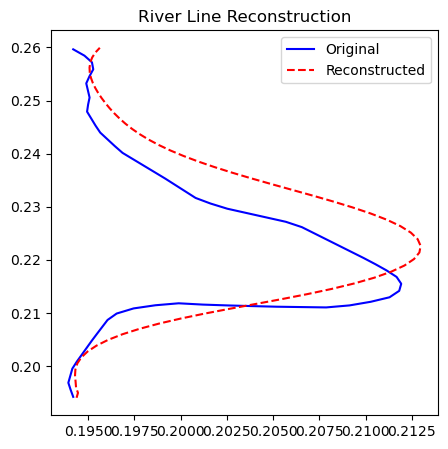

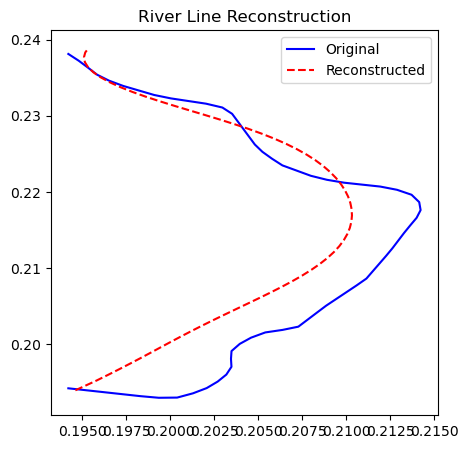

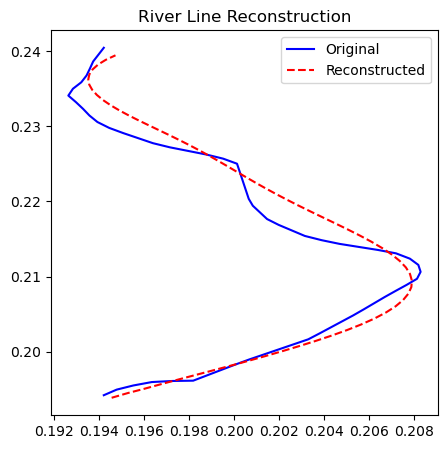

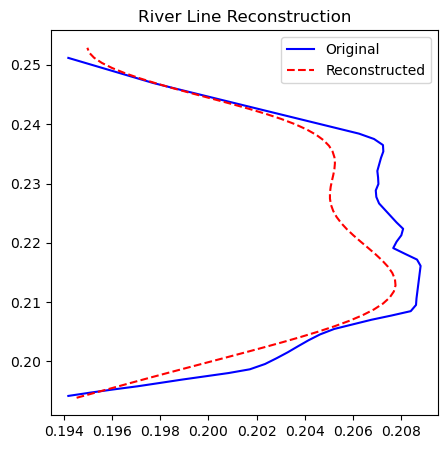

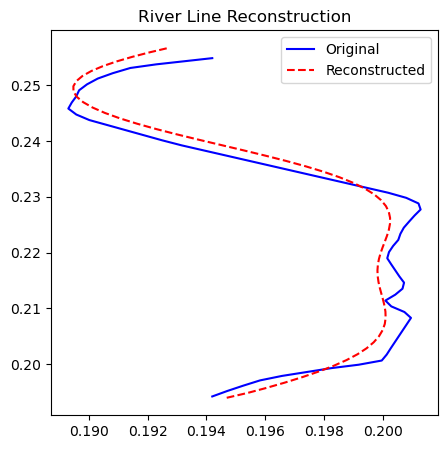

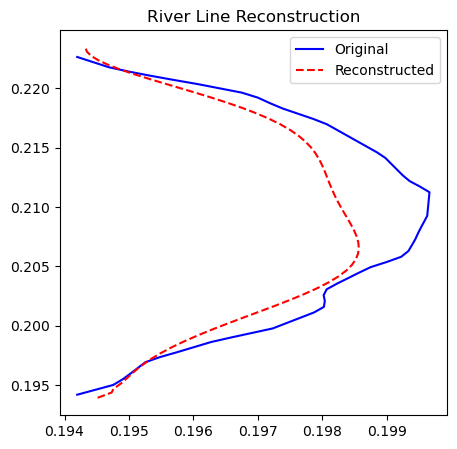

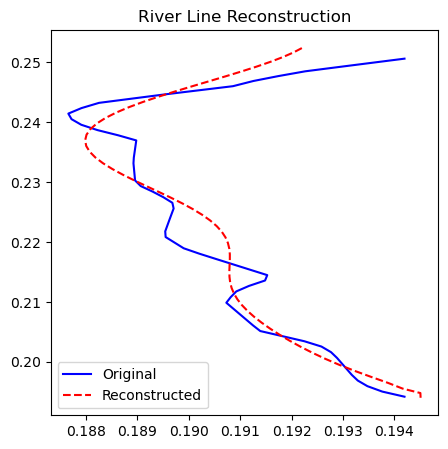

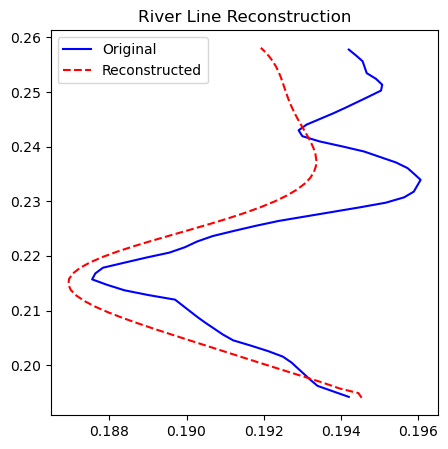

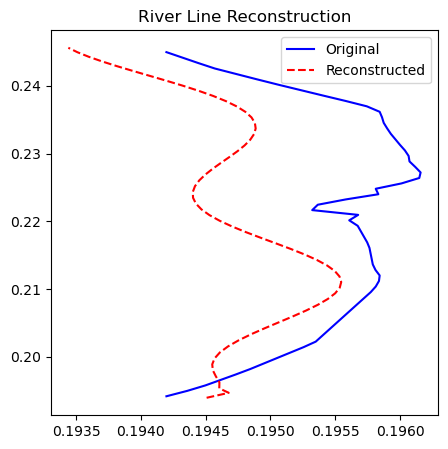

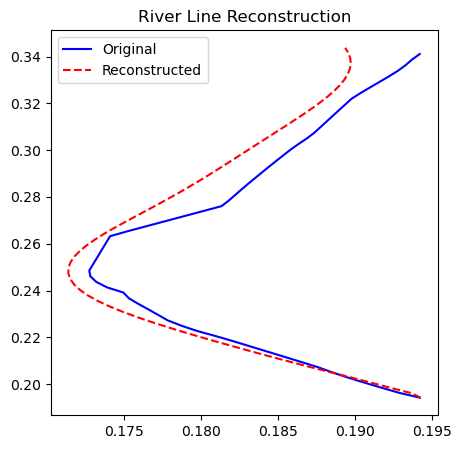

In [17]:
test_norm = np.load(PATH_TRAINING_A)[1200:1400]
reconstructed = autoencoder.predict(test_norm)

for i in range(20):
    plt.figure(figsize=(5,5))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], 'b-', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], 'r--', label='Reconstructed')
    plt.legend()
    plt.title('River Line Reconstruction')
    plt.show()


## SCRIPT

In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

# Suppose your data arrays are already loaded:
# train_data: (700, 64, 2)
# val_data: (150, 64, 2)
# test_data: (150, 64, 2)

# === Model architecture ===
timesteps = 64
features = 2
latent_dim = 16

inputs = Input(shape=(timesteps, features))
encoded = LSTM(64, return_sequences=True)(inputs)
encoded = LSTM(latent_dim)(encoded)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer=Adam(1e-3), loss='mse')

# === Training ===
history = autoencoder.fit(
    train_norm, train_norm,
    epochs=100,
    batch_size=32,
    shuffle=True
)

# === Reconstruction example ===
reconstructed = autoencoder.predict(test_norm)

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(5,5))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], 'b-', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], 'r--', label='Reconstructed')
    plt.legend()
    plt.title('River Line Reconstruction')
    plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, Dense

# Assume train_data: (700, 64, 2), test_data: (150, 64, 2)

# === Model definition ===
inputs = Input(shape=(64, 2))

# Encoder
x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)  # -> (8, 16)

# Decoder
x = Conv1D(16, 3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(32, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(64, 3, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
decoded = Conv1D(2, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mae')
autoencoder.summary()


In [ ]:
history = autoencoder.fit(
    train_norm, train_norm,
    epochs=300,
    batch_size=16,
    shuffle=True
)


In [ ]:
reconstructed = autoencoder.predict(test_norm)

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(5,5))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], 'b-', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], 'r--', label='Reconstructed')
    plt.legend()
    plt.title('River Line Reconstruction (Conv1D Autoencoder)')
    plt.show()
